Design, implement and evaluate a Convolutional Neural Network (CNN) model using a real-world dataset

In [1]:
import numpy as np

In [3]:
import os

In [30]:
import matplotlib.pyplot as plt

In [5]:
import tensorflow as tf

In [6]:
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
#Define dataset path

train_dir = "../seg_train/seg_train"
test_dir = "../seg_test/seg_test"

In [21]:
#Define image parameters

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

In [22]:
#Create training and validation datasets

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


In [24]:
#check the classes
class_names = train_ds.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6


In [25]:
#Load test data set

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 3000 files belonging to 6 classes.


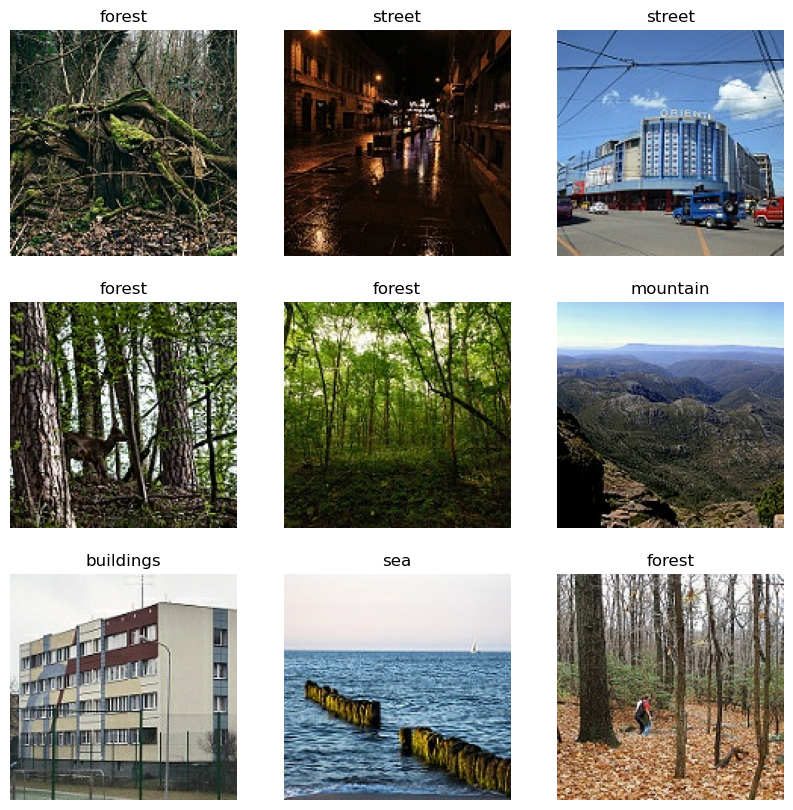

In [31]:
#Display sample images

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [32]:
#Normalize pixel values

normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

In [33]:
#Data augmentation

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
])

In [34]:
#CNN model

model = models.Sequential([

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(6, activation='softmax')
])

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
#Display model architecture

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
#Compile the model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Early stopping - checkpoint

In [37]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_cnn_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [38]:
#Train the model

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/30


C:\Users\User\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 106s 295ms/step - accuracy: 0.4946 - loss: 1.2757 - val_accuracy: 0.6194 - val_loss: 1.0075
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 110s 314ms/step - accuracy: 0.6120 - loss: 1.0275 - val_accuracy: 0.6361 - val_loss: 0.9857
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 103s 293ms/step - accuracy: 0.6528 - loss: 0.9358 - val_accuracy: 0.7021 - val_loss: 0.8241
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 102s 292ms/step - accuracy: 0.6862 - loss: 0.8597 - val_accuracy: 0.7234 - val_loss: 0.7124
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 103s 292ms/step - accuracy: 0.7097 - loss: 0.8087 - val_accuracy: 0.7356 - val_loss: 0.7173
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 103s 293ms/step - accuracy: 0.7265 - loss: 0.7720 - val_accuracy: 0.7701 - val_loss: 0.6492
Epoch 7/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 103s 292ms/step - accuracy: 0.7369 - loss: 0.7426 - val_accuracy: 0.7388 - val_loss: 0.7267
Epoch 8/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 103s 292ms/step - accuracy: 0.7421 - loss: 0.71

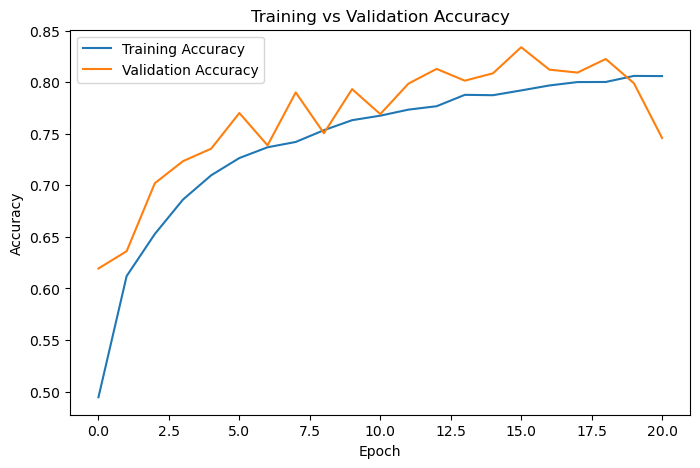

In [41]:
#Plot accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

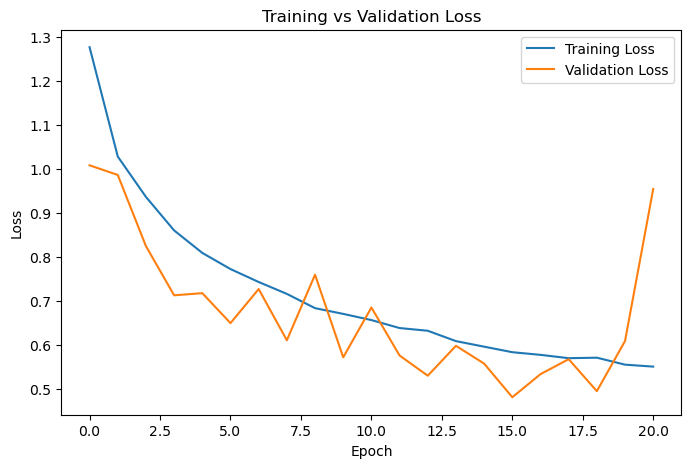

In [42]:
#Plot loss

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [43]:
#Model Evaluation

test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.8320 - loss: 0.4894
Test Loss: 0.4893643260002136
Test Accuracy: 0.8320000171661377


In [44]:
#Predictions

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [45]:
#Precision, Recall and F1-score

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

   buildings       0.84      0.79      0.81       437
      forest       0.93      0.98      0.95       474
     glacier       0.79      0.78      0.79       553
    mountain       0.83      0.72      0.77       525
         sea       0.79      0.85      0.82       510
      street       0.84      0.88      0.86       501

    accuracy                           0.83      3000
   macro avg       0.83      0.83      0.83      3000
weighted avg       0.83      0.83      0.83      3000



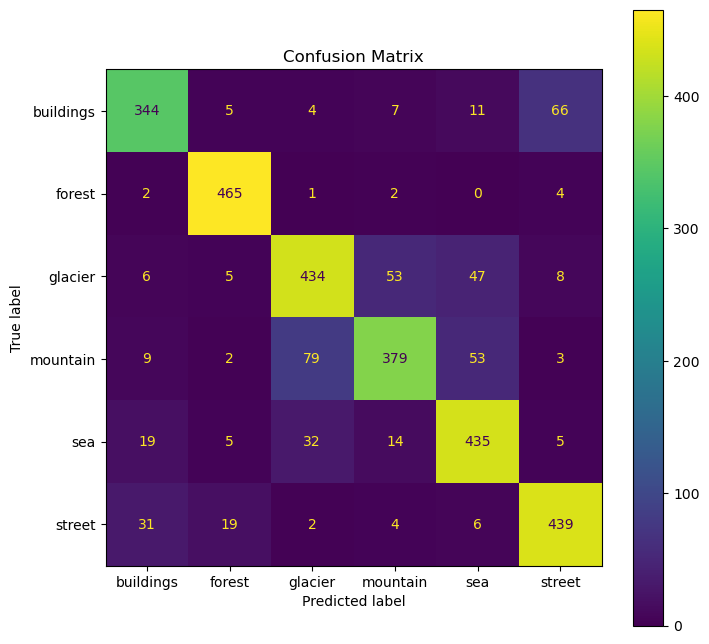

In [46]:
#Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(ax=ax)

plt.title("Confusion Matrix")
plt.show()

In [47]:
#Display 10 random predictions

# Collect all test images
test_images = []
test_labels = []

for images, labels in test_ds:
    test_images.extend(images.numpy())
    test_labels.extend(labels.numpy())

test_images = np.array(test_images)
test_labels = np.array(test_labels)

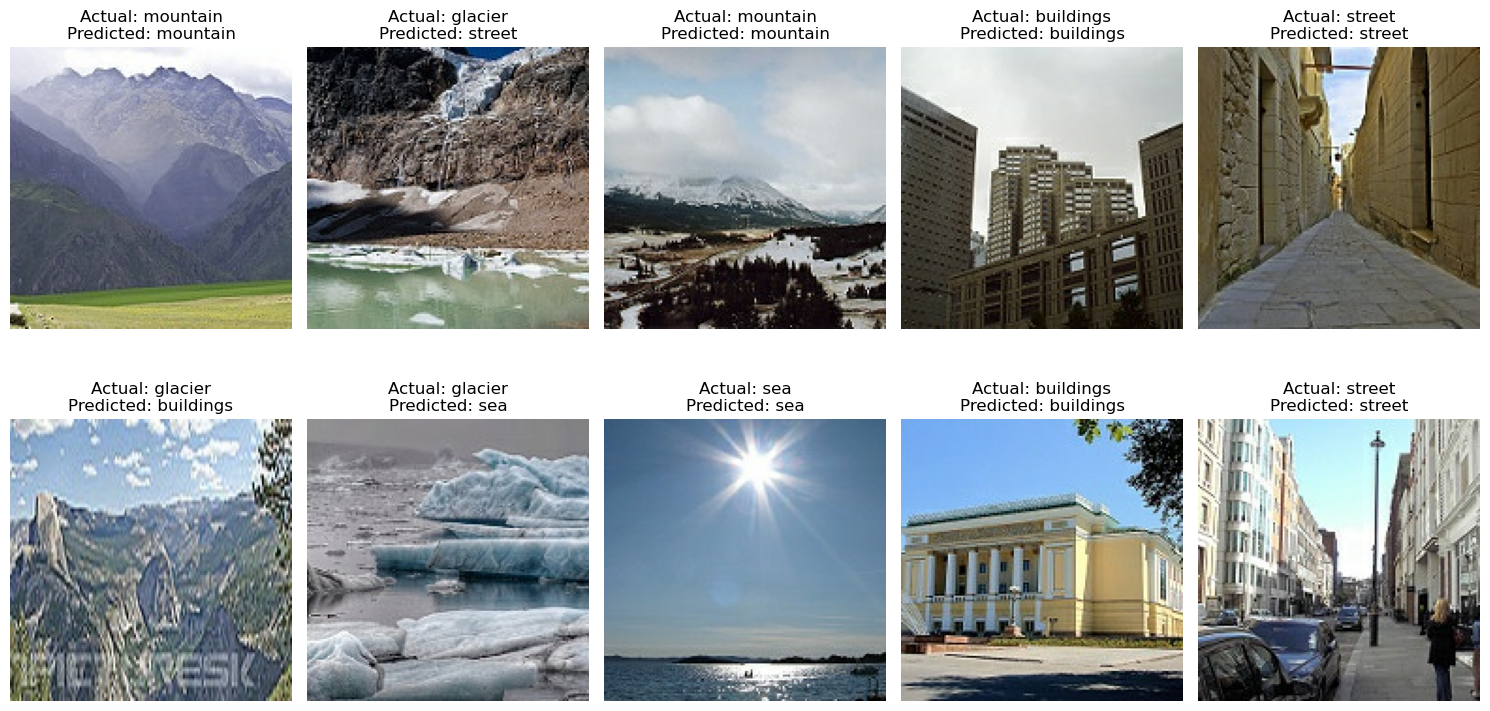

In [48]:

np.random.seed(42)

random_indices = np.random.choice(
    len(test_images),
    10,
    replace=False
)

plt.figure(figsize=(15, 8))

for i, index in enumerate(random_indices):

    image = test_images[index]

    prediction = model.predict(
        np.expand_dims(image, axis=0),
        verbose=0
    )

    predicted_class = np.argmax(prediction)

    actual_class = test_labels[index]

    ax = plt.subplot(2, 5, i + 1)

    plt.imshow(image)

    plt.title(
        f"Actual: {class_names[actual_class]}\n"
        f"Predicted: {class_names[predicted_class]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

Conclusion
---------
In this assignment, we built a CNN model to classify images into six different classes. We resized and normalized the images and used data augmentation to improve the model. The CNN was trained and tested using TensorFlow/Keras. We evaluated the model using accuracy, precision, recall, F1-score, and a confusion matrix. This assignment helped us understand how CNNs can be used for image classification.